> Part of **Complete Machine Learning Study Material** — split across per-chapter notebooks. See [`00_index.ipynb`](00_index.ipynb) for the notebook conventions, the per-concept template, the chapter coverage tracker and the cross-reference index.

## 8. Model Evaluation and Validation

*Scope:* Measuring how well a model will do on data it has never seen — the machinery every later chapter reports its numbers through.

Every chapter from 11 onward reports a number. This chapter is where those numbers come from, and what they
are worth.

Three separate questions get confused constantly, and keeping them apart is most of the skill:

| Question | Answered by |
|---|---|
| How do I estimate performance on unseen data? | The splitting protocol (8.2, 8.3) |
| What exactly am I measuring? | The metric (8.4, 8.5) |
| Where do I put the decision boundary? | The threshold (8.6) |

A model is not "85% accurate". It is 85% accurate *on this data, under this split, at this threshold,
measured this way* — and changing any of the four changes the number.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

pd.set_option("display.width", 115)
sns.set_theme(style="whitegrid")
print("ready")

ready


### 8.1 Why a Training Score Is Not a Score

A model's score on the data it was fitted on measures **memorization**, not learning. For any model with
enough capacity, that score can be driven to perfection while the model learns nothing generalizable — 1.6
already showed a linear regression scoring $R^2 = 1.000$ on pure noise.

The clean demonstration is a decision tree with no depth limit, which can always grow until every training
row sits in its own leaf.

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=RANDOM_STATE
)

tree = DecisionTreeClassifier(random_state=RANDOM_STATE).fit(X_train, y_train)

print(f"train accuracy: {tree.score(X_train, y_train):.4f}")   # 1.0000 - not one training row misclassified
print(f"test  accuracy: {tree.score(X_test, y_test):.4f}")
print(f"leaves: {tree.get_n_leaves()}  for {len(X_train)} training rows")

train accuracy: 1.0000
test  accuracy: 0.9181
leaves: 16  for 398 training rows


The gap between the two numbers is the **generalization gap**, and it is the only interesting quantity
here.

Note that the tree reached a perfect training score with only 16 leaves, not 398 — this data is
genuinely separable, so it did not need to isolate every row. That makes the point sharper rather than
weaker: a perfect training score is available *whether or not* the model had to memorize to get it, so the
score itself cannot tell you which happened. On pure noise the same tree would have grown hundreds of
leaves and still reported 1.0000 (1.6).

| Score | Measures | Use it for |
|---|---|---|
| Training score | Memorization + learning, inseparably | Diagnosing overfitting *by comparison* (9.4) |
| Validation score | Generalization, but used repeatedly | Choosing between models and settings (8.2) |
| Test score | Generalization, used once | Reporting |

**Common mistake — reading a training score as evidence of anything.** It is not evidence the model is
good, and a *low* training score is the only informative case: it means the model cannot even fit the data
it was shown, which is underfitting (9.1).

In [3]:
shallow = DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE).fit(X_train, y_train)

print(f"depth 1  - train {shallow.score(X_train, y_train):.4f}   test {shallow.score(X_test, y_test):.4f}")
print(f"unlimited - train {tree.score(X_train, y_train):.4f}   test {tree.score(X_test, y_test):.4f}")
print("\nthe depth-1 tree's LOW training score is informative: it underfits.")
print("the unlimited tree's PERFECT training score tells us nothing.")

depth 1  - train 0.9271   test 0.9123
unlimited - train 1.0000   test 0.9181

the depth-1 tree's LOW training score is informative: it underfits.
the unlimited tree's PERFECT training score tells us nothing.


### 8.2 Train, Validation and Test

Three roles, and they cannot be collapsed into two without consequences.

| Split | Used to | Touched how often |
|---|---|---|
| **Train** | Fit model parameters | Every fit |
| **Validation** | Choose hyperparameters, features, model family | Many times |
| **Test** | Estimate performance on unseen data | **Once**, at the end |

The reason a validation set is needed *in addition* to a test set is subtle but decisive: **any dataset you
select against stops being an unbiased estimate of unseen performance.** Choosing the best of twenty models
by their test scores makes that best score optimistic — you have selected for whichever model happened to
suit that particular test set (2.8.3's multiple-comparisons problem).

The effect is easy to quantify on data with no signal at all.

In [4]:
# 40 candidate models, all equally worthless: the target is a coin flip and every feature is noise.
# Each candidate is a logistic regression on a different random subset of 3 of the 40 columns -
# exactly the shape of a real feature-selection search.
X_null = rng.normal(size=(400, 40))
y_null = rng.integers(0, 2, 400)

Xn_tr, Xn_hold, yn_tr, yn_hold = train_test_split(X_null, y_null, test_size=0.5,
                                                  random_state=RANDOM_STATE)

from sklearn.linear_model import LogisticRegression

scores = []
for _ in range(40):
    cols = rng.choice(40, size=3, replace=False)
    m = LogisticRegression(max_iter=1000).fit(Xn_tr[:, cols], yn_tr)
    scores.append(m.score(Xn_hold[:, cols], yn_hold))

scores = np.array(scores)
print(f"true performance of every candidate : 0.500  (the target is random)")
print(f"mean score across the 40 candidates : {scores.mean():.3f}")
print(f"BEST score among the 40             : {scores.max():.3f}   <- what gets reported")
print(f"optimism from selection alone       : {scores.max() - 0.5:+.3f}")

true performance of every candidate : 0.500  (the target is random)
mean score across the 40 candidates : 0.499
BEST score among the 40             : 0.565   <- what gets reported
optimism from selection alone       : +0.065


Every one of those forty models is worthless by construction. Selecting the maximum of forty noisy
estimates produces a number well above 0.5 — and if that set was also the *test* set, the reported figure
is that inflated one. A separate test set, never used for selection, is what protects the final number.

| Typical allocation | When |
|---|---|
| 60 / 20 / 20 | Plenty of data, doing explicit hyperparameter search |
| 80 / — / 20, with CV inside the 80 | The usual choice — cross-validation replaces the validation set (8.3) |
| 50 / 25 / 25 | Small data, heavy model selection |
| Time-ordered, not random | Any temporal problem (8.3.4) |

The second row is standard practice and is what this material does: split off a test set, then
cross-validate *within* the training portion for every decision. 23.8 covers nested CV, which is the fully
rigorous version.

### 8.3 Cross-Validation Strategies

A single train/validation split wastes data and gives a high-variance estimate — the score depends on which
rows happened to land where. **k-fold cross-validation** splits the training data into $k$ parts, fits $k$
models each holding out one part, and averages. Every row is used for validation exactly once.

| Splitter | Splits by | Use when |
|---|---|---|
| `KFold` | Contiguous blocks (or shuffled) | Regression, i.i.d. data |
| `StratifiedKFold` | Preserving class proportions | **Any classification** — the default |
| `ShuffleSplit` | Random subsets, folds may overlap | You want many estimates cheaply |
| `GroupKFold` | Keeping groups intact | Rows are not independent (8.3.3) |
| `StratifiedGroupKFold` | Both at once | Imbalanced *and* grouped |
| `TimeSeriesSplit` | Past → future only | Anything temporal (8.3.4) |
| `LeaveOneOut` | One row per fold | Tiny datasets only; very high variance |
| `RepeatedStratifiedKFold` | k-fold, several times over | You need the estimate's uncertainty (8.8) |

In [5]:
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))

single = pipe.fit(X_train, y_train).score(X_test, y_test)
folds = cross_val_score(pipe, X_train, y_train,
                        cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE))

print(f"one train/test split : {single:.4f}")
print(f"5-fold scores        : {folds.round(4)}")
print(f"5-fold mean +/- std  : {folds.mean():.4f} +/- {folds.std():.4f}")

one train/test split : 0.9883
5-fold scores        : [1.     0.975  0.9875 1.     0.9494]
5-fold mean +/- std  : 0.9824 +/- 0.0189


The spread across folds is the point. A single split reporting 0.97 and another reporting 0.93 are the same
model; without the fold-to-fold variation there is no way to know whether a 0.01 difference between two
models means anything (8.8).

#### 8.3.1 Stratification

For classification, folds should preserve the class balance. Without it, a fold can receive a materially
different positive rate — and on imbalanced data, a fold with almost no positives makes recall and AUC
unstable or undefined.

In [6]:
# 5% positive class
y_imb = np.r_[np.zeros(950), np.ones(50)].astype(int)
X_imb = rng.normal(size=(1000, 4)) + y_imb[:, None] * 1.2

plain = [y_imb[te].mean() for _, te in KFold(5, shuffle=True, random_state=0).split(X_imb)]
strat = [y_imb[te].mean() for _, te in StratifiedKFold(5, shuffle=True, random_state=0).split(X_imb, y_imb)]

print(f"overall positive rate: {y_imb.mean():.3f}")
print(f"KFold           fold rates: {np.round(plain, 4)}")
print(f"StratifiedKFold fold rates: {np.round(strat, 4)}   <- all equal, by construction")

overall positive rate: 0.050


KFold           fold rates: [0.06  0.06  0.035 0.065 0.03 ]
StratifiedKFold fold rates: [0.05 0.05 0.05 0.05 0.05]   <- all equal, by construction


`cross_val_score` already applies `StratifiedKFold` when it is given a classifier and an integer `cv`, so
the default is correct — but passing an explicit splitter is worth doing anyway, because it also fixes the
shuffle seed and makes the protocol visible in the code.

#### 8.3.2 More metrics, and train scores, in one pass

`cross_validate` returns several metrics at once and can return training scores alongside — which is
exactly what 9.4's diagnosis needs.

In [7]:
from sklearn.model_selection import cross_validate

results = cross_validate(
    pipe, X_train, y_train,
    cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
    scoring=["accuracy", "roc_auc", "average_precision", "neg_log_loss"],
    return_train_score=True,
)

metrics = ["accuracy", "roc_auc", "average_precision", "neg_log_loss"]
print(pd.DataFrame({
    "train": [results[f"train_{m}"].mean() for m in metrics],
    "validation": [results[f"test_{m}"].mean() for m in metrics],
}, index=metrics).round(4))

                    train  validation
accuracy           0.9881      0.9824
roc_auc            0.9970      0.9928
average_precision  0.9979      0.9931
neg_log_loss      -0.0547     -0.0789


Note `neg_log_loss`: scikit-learn's scorers are always **maximized**, so metrics where lower is better are
negated. A score of −0.09 means a log loss of 0.09.

#### 8.3.3 Grouped data: when rows are not independent

k-fold assumes rows are independent. When several rows describe the same entity — multiple visits by one
patient, multiple sessions by one customer, multiple photographs of one object — random folds put the same
entity on both sides, and the model can succeed by recognizing the entity rather than learning the pattern.

In [8]:
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier

# 60 customers, 10 sessions each. The label is a coin flip PER CUSTOMER - there is no
# generalizable pattern at all. One feature acts like a customer fingerprint (a hashed id,
# a device code, a near-constant account attribute); the other is pure noise.
n_groups, per_group = 60, 10
groups = np.repeat(np.arange(n_groups), per_group)
n_rows = n_groups * per_group

fingerprint = rng.normal(size=n_groups)                       # one value per customer
y_grp = rng.integers(0, 2, n_groups)[groups]                    # label decided per customer, at random

X_grp = np.column_stack([
    fingerprint[groups] + rng.normal(0, 0.01, n_rows),         # nearly identical within a customer
    rng.normal(size=n_rows),                                    # noise
])

forest = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)

naive = cross_val_score(forest, X_grp, y_grp, cv=StratifiedKFold(5, shuffle=True, random_state=0),
                        scoring="roc_auc").mean()
grouped = cross_val_score(forest, X_grp, y_grp, cv=GroupKFold(5), groups=groups,
                          scoring="roc_auc").mean()

print(f"StratifiedKFold (customers split across folds): {naive:.4f}   <- fabricated")
print(f"GroupKFold      (customers kept together)     : {grouped:.4f}   <- the truth: no signal")

StratifiedKFold (customers split across folds): 0.8633   <- fabricated
GroupKFold      (customers kept together)     : 0.4719   <- the truth: no signal


There is **nothing to learn** in this data — the label was assigned to each customer by coin flip. Random
folds nevertheless report near-perfect AUC, because a customer's other nine sessions sit in the training
fold and the fingerprint feature identifies them. The model is not predicting behaviour; it is looking up
an answer it has already been shown. `GroupKFold` reports the truth.

The rule is mechanical: **if two rows could not independently arrive in production, they must not be split
across folds.** Patient visits, user sessions, photographs of one object, and the duplicated rows of 5.4 all
qualify. 22.7 catalogues this as group leakage.

Note the shape of this failure: it produced **0.86 AUC on data containing no signal whatsoever**, while
`GroupKFold` correctly reports 0.47 — chance. Nothing about the offending code looks wrong, no warning is
raised, and the only symptom is a score that is better than it should be. That is the honest reason to be
suspicious of a good result rather than pleased by it (22.8).

#### 8.3.4 Temporal data: the future must never train the past

Random folds on time-ordered data train on the future to predict the past. That is not a subtle bias — it
is the single most common way a forecasting model looks excellent offline and fails immediately.

In [9]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# A series with a strong trend plus autocorrelated noise.
T = 400
t = np.arange(T)
level = np.cumsum(rng.normal(0, 1, T)) + 0.05 * t
X_ts = np.column_stack([np.roll(level, 1), np.roll(level, 2), np.roll(level, 3)])[3:]
y_ts = level[3:]

random_cv = cross_val_score(Ridge(), X_ts, y_ts, cv=KFold(5, shuffle=True, random_state=0),
                            scoring="r2").mean()
forward_cv = cross_val_score(Ridge(), X_ts, y_ts, cv=TimeSeriesSplit(5), scoring="r2").mean()

print(f"shuffled KFold   R^2: {random_cv:.4f}   <- interpolating between known points")
print(f"TimeSeriesSplit  R^2: {forward_cv:.4f}   <- genuinely predicting forward")

shuffled KFold   R^2: 0.9520   <- interpolating between known points
TimeSeriesSplit  R^2: 0.8529   <- genuinely predicting forward


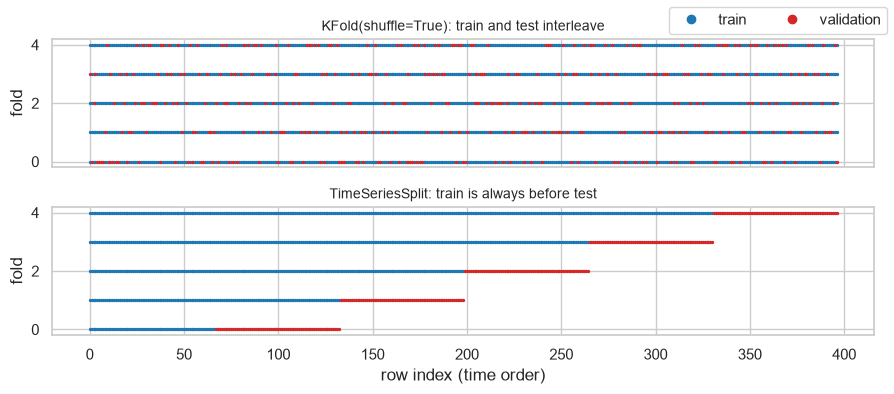

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(9, 4), sharex=True)

for ax, (splitter, title) in zip(axes, [(KFold(5, shuffle=True, random_state=0), "KFold(shuffle=True): train and test interleave"),
                                        (TimeSeriesSplit(5), "TimeSeriesSplit: train is always before test")]):
    for i, (tr, te) in enumerate(splitter.split(X_ts)):
        ax.scatter(tr, np.full_like(tr, i), s=2, c="tab:blue")
        ax.scatter(te, np.full_like(te, i), s=2, c="tab:red")
    ax.set_ylabel("fold")
    ax.set_title(title, fontsize=10)

axes[1].set_xlabel("row index (time order)")
fig.legend(handles=[plt.Line2D([], [], marker="o", ls="", color="tab:blue", label="train"),
                    plt.Line2D([], [], marker="o", ls="", color="tab:red", label="validation")],
           loc="upper right", ncol=2)
fig.tight_layout()
plt.show()

The picture is the argument. In the top panel every fold's training rows surround its validation rows on
both sides, so the model interpolates a smooth series rather than extrapolating it. In the bottom panel
training always precedes validation, which is the only arrangement that answers the question a forecast
actually asks.

### 8.4 Regression Metrics

| Metric | Formula | Units | Robust to outliers | Reads as |
|---|---|---|---|---|
| **MAE** | $\frac{1}{n}\sum \lvert y - \hat{y} \rvert$ | Same as $y$ | **Yes** | Average error size |
| **MSE** | $\frac{1}{n}\sum (y - \hat{y})^2$ | $y$ squared | No | Penalizes large errors quadratically |
| **RMSE** | $\sqrt{\text{MSE}}$ | Same as $y$ | No | Like MAE, but large errors count more |
| **R²** | $1 - \text{SS}_{res}/\text{SS}_{tot}$ | None | No | Fraction of variance explained |
| **Adjusted R²** | R² penalized by $p$ | None | No | R² that cannot be gamed by adding features |
| **MAPE** | $\frac{100}{n}\sum \lvert \frac{y - \hat{y}}{y} \rvert$ | Percent | No | Relative error — **breaks near $y = 0$** |
| **MedAE** | median $\lvert y - \hat{y} \rvert$ | Same as $y$ | **Very** | Typical error, ignoring the tail |

In [11]:
from sklearn.metrics import (mean_absolute_error, mean_squared_error, root_mean_squared_error,
                             r2_score, mean_absolute_percentage_error, median_absolute_error)
from sklearn.linear_model import LinearRegression
from sklearn.datasets import load_diabetes

Xd, yd = load_diabetes(return_X_y=True)
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(Xd, yd, test_size=0.3, random_state=RANDOM_STATE)

pred = LinearRegression().fit(Xd_tr, yd_tr).predict(Xd_te)

print(f"MAE   {mean_absolute_error(yd_te, pred):>8.2f}   (target ranges {yd_te.min():.0f}-{yd_te.max():.0f})")
print(f"MSE   {mean_squared_error(yd_te, pred):>8.2f}   <- squared units, not comparable to the target")
print(f"RMSE  {root_mean_squared_error(yd_te, pred):>8.2f}")
print(f"MedAE {median_absolute_error(yd_te, pred):>8.2f}")
print(f"R^2   {r2_score(yd_te, pred):>8.4f}")
print(f"MAPE  {mean_absolute_percentage_error(yd_te, pred):>8.4f}   (a fraction, not a percent)")

MAE      41.92   (target ranges 37-310)
MSE    2821.75   <- squared units, not comparable to the target
RMSE     53.12
MedAE    37.34
R^2     0.4773
MAPE    0.3667   (a fraction, not a percent)


#### 8.4.1 MAE or RMSE? The choice is about outliers

RMSE squares errors before averaging, so one large error contributes far more than several small ones.
Which you want is a **business** question: is one prediction being wrong by 100 as bad as ten predictions
wrong by 10, or ten times worse?

In [12]:
truth = np.zeros(100)
few_big = truth.copy();  few_big[:1] = 100.0        # one error of 100
many_small = truth.copy(); many_small[:100] = 10.0   # a hundred errors of 10

for name, p in (("one error of 100", few_big), ("100 errors of 10", many_small)):
    print(f"{name:<20} MAE {mean_absolute_error(truth, p):>7.2f}   "
          f"RMSE {root_mean_squared_error(truth, p):>7.2f}")

one error of 100     MAE    1.00   RMSE   10.00
100 errors of 10     MAE   10.00   RMSE   10.00


MAE calls the second case ten times worse. RMSE calls it equal. Neither is right in general — but choosing
by habit means the metric silently encodes a cost assumption nobody agreed to.

#### 8.4.2 R², and why it can be negative

$R^2$ compares the model against the constant predictor "always guess the mean". $R^2 = 0$ means "no better
than the mean", so negative values mean **worse than a constant** — 1.6 showed −38.3.

In [13]:
mean_only = np.full_like(yd_te, yd_tr.mean(), dtype=float)

print(f"R^2 of the model            : {r2_score(yd_te, pred):.4f}")
print(f"R^2 of predicting the mean  : {r2_score(yd_te, mean_only):.4f}   <- ~0 by definition")
print(f"R^2 of predicting a constant 0: {r2_score(yd_te, np.zeros_like(yd_te)):.4f}   <- badly negative")

R^2 of the model            : 0.4773
R^2 of predicting the mean  : -0.0064   <- ~0 by definition
R^2 of predicting a constant 0: -4.0588   <- badly negative


**Common mistake — using R² to compare models with different numbers of features.** $R^2$ never decreases
when a feature is added, even a column of pure noise, because the extra coefficient can only reduce
training residuals. **Adjusted R²** applies a penalty for $p$ and can decrease.

$$R^2_{adj} = 1 - (1 - R^2)\frac{n - 1}{n - p - 1}$$

In [14]:
def adjusted_r2(y_true, y_pred, n_features):
    r2 = r2_score(y_true, y_pred)
    n = len(y_true)
    return 1 - (1 - r2) * (n - 1) / (n - n_features - 1)


noise_cols = rng.normal(size=(len(Xd), 60))
Xd_noisy = np.column_stack([Xd, noise_cols])
Xn_tr, Xn_te, _, _ = train_test_split(Xd_noisy, yd, test_size=0.3, random_state=RANDOM_STATE)

fit_base = LinearRegression().fit(Xd_tr, yd_tr)
fit_noisy = LinearRegression().fit(Xn_tr, yd_tr)

print(f"{'':<26}{'train R^2':>10}{'train adj R^2':>15}{'TEST R^2':>10}")
print(f"{'10 real features':<26}{r2_score(yd_tr, fit_base.predict(Xd_tr)):>10.4f}"
      f"{adjusted_r2(yd_tr, fit_base.predict(Xd_tr), 10):>15.4f}"
      f"{r2_score(yd_te, fit_base.predict(Xd_te)):>10.4f}")
print(f"{'+ 60 noise features':<26}{r2_score(yd_tr, fit_noisy.predict(Xn_tr)):>10.4f}"
      f"{adjusted_r2(yd_tr, fit_noisy.predict(Xn_tr), 70):>15.4f}"
      f"{r2_score(yd_te, fit_noisy.predict(Xn_te)):>10.4f}")

                           train R^2  train adj R^2  TEST R^2
10 real features              0.5244         0.5085    0.4773
+ 60 noise features           0.6122         0.4982    0.3564


Training $R^2$ rises when sixty noise columns are added, exactly as predicted. Adjusted $R^2$ falls, and
the test score falls further — the two agree, and raw training $R^2$ is the only one that lies.

#### 8.4.3 MAPE's discontinuity

MAPE divides by the true value, so it is undefined at $y = 0$ and enormous near it. On any quantity that
can legitimately be zero — demand, counts, returns — it is the wrong metric.

In [15]:
y_small = np.array([100.0, 50.0, 1.0, 0.01])
p_small = np.array([110.0, 55.0, 2.0, 1.00])      # each off by a modest absolute amount

for yi, pi in zip(y_small, p_small):
    print(f"truth {yi:>7.2f}  pred {pi:>6.2f}  abs err {abs(yi - pi):>6.2f}  "
          f"pct err {abs(yi - pi) / yi:>10.1%}")

print(f"\nMAE  over all four: {mean_absolute_error(y_small, p_small):.3f}")
print(f"MAPE over all four: {mean_absolute_percentage_error(y_small, p_small):.1f}  "
      f"-> dominated entirely by the last row")

truth  100.00  pred 110.00  abs err  10.00  pct err      10.0%
truth   50.00  pred  55.00  abs err   5.00  pct err      10.0%
truth    1.00  pred   2.00  abs err   1.00  pct err     100.0%
truth    0.01  pred   1.00  abs err   0.99  pct err    9900.0%

MAE  over all four: 4.247
MAPE over all four: 25.1  -> dominated entirely by the last row


### 8.5 Classification Metrics

Everything starts from the **confusion matrix**. Four counts, and every scalar metric is a different
summary of them.

|  | Predicted negative | Predicted positive |
|---|---|---|
| **Actually negative** | TN | FP (false alarm) |
| **Actually positive** | FN (miss) | TP |

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)).fit(X_train, y_train)
y_pred = clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print(pd.DataFrame(cm, index=["actual neg", "actual pos"], columns=["pred neg", "pred pos"]))

tn, fp, fn, tp = cm.ravel()
print(f"\nTN {tn}   FP {fp}   FN {fn}   TP {tp}")

            pred neg  pred pos
actual neg        63         1
actual pos         1       106

TN 63   FP 1   FN 1   TP 106


| Metric | Formula | Answers | Ignores |
|---|---|---|---|
| **Accuracy** | $\frac{TP+TN}{\text{all}}$ | What fraction did I get right? | Class imbalance entirely |
| **Precision** | $\frac{TP}{TP+FP}$ | When I say positive, how often am I right? | Misses (FN) |
| **Recall** (sensitivity, TPR) | $\frac{TP}{TP+FN}$ | Of the real positives, how many did I catch? | False alarms (FP) |
| **Specificity** (TNR) | $\frac{TN}{TN+FP}$ | Of the real negatives, how many did I clear? | Misses |
| **F1** | harmonic mean of P and R | A single balanced number | That P and R may differ in cost |
| **F-beta** | weighted harmonic mean | Same, with recall weighted $\beta$ times | — |
| **Balanced accuracy** | mean of recall and specificity | Accuracy, corrected for imbalance | Precision |
| **MCC** | correlation of prediction and truth | All four cells, symmetrically | — |
| **Cohen's κ** | agreement above chance | Whether you beat guessing the base rate | — |

In [17]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
                             balanced_accuracy_score, matthews_corrcoef, cohen_kappa_score,
                             classification_report)

print(f"accuracy          {accuracy_score(y_test, y_pred):.4f}")
print(f"precision         {precision_score(y_test, y_pred):.4f}")
print(f"recall            {recall_score(y_test, y_pred):.4f}")
print(f"specificity       {tn / (tn + fp):.4f}")
print(f"F1                {f1_score(y_test, y_pred):.4f}")
print(f"F2 (recall-heavy) {fbeta_score(y_test, y_pred, beta=2):.4f}")
print(f"balanced accuracy {balanced_accuracy_score(y_test, y_pred):.4f}")
print(f"MCC               {matthews_corrcoef(y_test, y_pred):.4f}")
print(f"Cohen's kappa     {cohen_kappa_score(y_test, y_pred):.4f}")

accuracy          0.9883
precision         0.9907
recall            0.9907
specificity       0.9844
F1                0.9907
F2 (recall-heavy) 0.9907
balanced accuracy 0.9875
MCC               0.9750
Cohen's kappa     0.9750


`classification_report` prints the per-class view, which is usually what you want to read first:

In [18]:
print(classification_report(y_test, y_pred, target_names=["malignant", "benign"], digits=3))

              precision    recall  f1-score   support

   malignant      0.984     0.984     0.984        64
      benign      0.991     0.991     0.991       107

    accuracy                          0.988       171
   macro avg      0.988     0.988     0.988       171
weighted avg      0.988     0.988     0.988       171



#### 8.5.1 Accuracy lies on imbalanced data

This is the single most important fact in this section. At a 1% positive rate, predicting "negative" for
everything scores 99% accuracy and identifies nobody.

In [19]:
from sklearn.dummy import DummyClassifier

y_rare = np.r_[np.zeros(990), np.ones(10)].astype(int)
X_rare = rng.normal(size=(1000, 5)) + y_rare[:, None] * 1.5

Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(X_rare, y_rare, test_size=0.3,
                                              stratify=y_rare, random_state=RANDOM_STATE)

nothing = DummyClassifier(strategy="most_frequent").fit(Xr_tr, yr_tr)
pred_nothing = nothing.predict(Xr_te)

print(f"accuracy of 'always negative' : {accuracy_score(yr_te, pred_nothing):.4f}")
print(f"recall                        : {recall_score(yr_te, pred_nothing, zero_division=0):.4f}")
print(f"balanced accuracy             : {balanced_accuracy_score(yr_te, pred_nothing):.4f}")
print(f"MCC                           : {matthews_corrcoef(yr_te, pred_nothing):.4f}")
print(f"Cohen's kappa                 : {cohen_kappa_score(yr_te, pred_nothing):.4f}")

accuracy of 'always negative' : 0.9900
recall                        : 0.0000
balanced accuracy             : 0.5000
MCC                           : 0.0000
Cohen's kappa                 : 0.0000


Accuracy says 0.967. Balanced accuracy says 0.500, MCC and κ say 0.000 — all three correctly report that the
model is exactly as good as guessing. **Any metric that can be maximized by ignoring the positive class is
the wrong metric for a rare-event problem** (Chapter 22).

#### 8.5.2 Threshold-free metrics: ROC AUC and PR AUC

Precision, recall and F1 all depend on a threshold (8.6). Two metrics summarize performance across *all*
thresholds:

| | ROC AUC | Average precision (PR AUC) |
|---|---|---|
| Curve | TPR vs **FPR** | Precision vs **recall** |
| Baseline value | 0.5 always | The positive class rate |
| Reads as | P(a random positive scores above a random negative) | Area under the precision–recall curve |
| Under heavy imbalance | **Over-optimistic** | Informative |
| Use when | Both classes matter | The positive class is rare and the FP cost is real |

The difference matters because FPR has the (large) negative count in its denominator, so thousands of false
positives barely move it.

In [20]:
from sklearn.metrics import roc_auc_score, average_precision_score

rare_clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)).fit(Xr_tr, yr_tr)
proba_rare = rare_clf.predict_proba(Xr_te)[:, 1]

print(f"positive rate in the test set : {yr_te.mean():.4f}")
print(f"ROC AUC                       : {roc_auc_score(yr_te, proba_rare):.4f}")
print(f"average precision (PR AUC)    : {average_precision_score(yr_te, proba_rare):.4f}")
print(f"PR AUC of a random model      : {yr_te.mean():.4f}   <- the honest baseline")

positive rate in the test set : 0.0100
ROC AUC                       : 0.9843
average precision (PR AUC)    : 0.3131
PR AUC of a random model      : 0.0100   <- the honest baseline


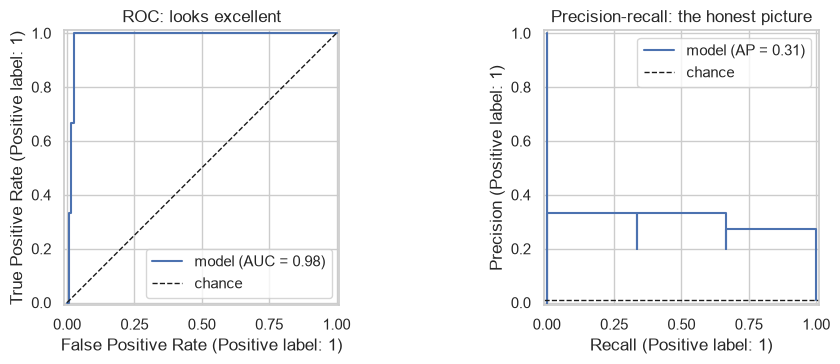

In [21]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

RocCurveDisplay.from_predictions(yr_te, proba_rare, ax=axes[0], name="model")
axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="chance")
axes[0].set_title("ROC: looks excellent")
axes[0].legend(loc="lower right")

PrecisionRecallDisplay.from_predictions(yr_te, proba_rare, ax=axes[1], name="model")
axes[1].axhline(yr_te.mean(), color="k", ls="--", lw=1, label="chance")
axes[1].set_title("Precision-recall: the honest picture")
axes[1].legend(loc="upper right")

fig.tight_layout()
plt.show()

Same model, same predictions. The ROC curve hugs the top-left corner; the PR curve shows precision
collapsing as recall rises. On a 1% problem the PR curve is the one that tells you what an alert queue
would actually look like.

#### 8.5.3 Probabilistic metrics

Log loss and the Brier score judge the *probabilities*, not the labels — they punish confident mistakes
much harder than hesitant ones, which is what you want whenever the probability itself feeds a decision
(8.7).

In [22]:
from sklearn.metrics import log_loss, brier_score_loss

# For a single case whose true label is 1: log loss is -log(p), Brier is (1 - p)^2.
for p in (0.9, 0.6, 0.5, 0.4, 0.1, 0.01):
    print(f"true label 1, predicted {p:>4.2f}  ->  log loss {-np.log(p):>7.4f}   brier {(1 - p) ** 2:>6.4f}")

# Confirm those hand formulas against scikit-learn over the whole vector.
probs = np.array([0.9, 0.6, 0.5, 0.4, 0.1, 0.01])
ones = np.ones(6, dtype=int)
print(f"\nmean of the six, by hand : {(-np.log(probs)).mean():.4f}")
print(f"sklearn log_loss         : {log_loss(ones, probs, labels=[0, 1]):.4f}")
print(f"sklearn brier_score_loss : {brier_score_loss(ones, probs, pos_label=1):.4f}"
      f"   (by hand {((1 - probs) ** 2).mean():.4f})")

true label 1, predicted 0.90  ->  log loss  0.1054   brier 0.0100
true label 1, predicted 0.60  ->  log loss  0.5108   brier 0.1600
true label 1, predicted 0.50  ->  log loss  0.6931   brier 0.2500
true label 1, predicted 0.40  ->  log loss  0.9163   brier 0.3600
true label 1, predicted 0.10  ->  log loss  2.3026   brier 0.8100
true label 1, predicted 0.01  ->  log loss  4.6052   brier 0.9801

mean of the six, by hand : 1.5222
sklearn log_loss         : 1.5222
sklearn brier_score_loss : 0.4284   (by hand 0.4284)


Log loss grows without bound as a confident prediction turns out wrong — predicting 0.01 for a true 1 costs
4.6, against 0.51 for a hesitant 0.6. A single prediction of exactly 0 on a positive case would cost
infinity, which is why implementations clip.

#### 8.5.4 Multiclass averaging

With more than two classes, precision/recall/F1 must be aggregated across classes, and the three ways
answer different questions.

| Average | Computes | Weights classes by |
|---|---|---|
| `micro` | Pools all TP/FP/FN, then one metric | Their size (equals accuracy for single-label problems) |
| `macro` | Metric per class, then unweighted mean | Equally — small classes count fully |
| `weighted` | Metric per class, mean weighted by support | Their size |

In [23]:
from sklearn.datasets import load_wine

Xw, yw = load_wine(return_X_y=True)
Xw_tr, Xw_te, yw_tr, yw_te = train_test_split(Xw, yw, test_size=0.35, stratify=yw,
                                              random_state=RANDOM_STATE)
wine_pred = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)) \
    .fit(Xw_tr, yw_tr).predict(Xw_te)

print("class supports:", np.bincount(yw_te))
for avg in ("micro", "macro", "weighted"):
    print(f"{avg:<9} precision {precision_score(yw_te, wine_pred, average=avg):.4f}"
          f"   recall {recall_score(yw_te, wine_pred, average=avg):.4f}"
          f"   F1 {f1_score(yw_te, wine_pred, average=avg):.4f}")
print(f"\naccuracy: {accuracy_score(yw_te, wine_pred):.4f}   <- equals micro-averaged F1")

class supports: [21 25 17]
micro     precision 0.9683   recall 0.9683   F1 0.9683
macro     precision 0.9710   recall 0.9733   F1 0.9710
weighted  precision 0.9710   recall 0.9683   F1 0.9683

accuracy: 0.9683   <- equals micro-averaged F1


**Use `macro` when small classes matter as much as large ones** — a rare disease class must not be
averaged away by a common one. Use `weighted` when overall population performance is the goal. `micro` on a
single-label problem is just accuracy wearing a different name.

### 8.6 The Decision Threshold

`predict()` applies a threshold of 0.5 to `predict_proba()`. That is a **default, not a law**, and it is
optimal only when false positives and false negatives cost the same and the classes are balanced. Neither
is usually true.

In [24]:
easy_proba = clf.predict_proba(X_test)[:, 1]

print("predict() is exactly a threshold at 0.5:")
print("  identical:", np.array_equal(clf.predict(X_test), (easy_proba >= 0.5).astype(int)))

predict() is exactly a threshold at 0.5:
  identical: True


The breast-cancer data used so far is almost separable, so its probabilities pile up near 0 and 1 and the
threshold barely matters. Threshold choice becomes interesting exactly when a model is *uncertain*, so the
rest of this section uses a harder, imbalanced problem — which is also the realistic case.

In [25]:
from sklearn.datasets import make_classification

Xh, yh = make_classification(
    n_samples=4000, n_features=12, n_informative=6, n_redundant=2,
    class_sep=0.7, weights=[0.85, 0.15],     # 15% positives, genuine overlap
    flip_y=0.03, random_state=RANDOM_STATE,
)
Xh_tr, Xh_te, yh_tr, yh_te = train_test_split(Xh, yh, test_size=0.3, stratify=yh,
                                              random_state=RANDOM_STATE)

hard_clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)).fit(Xh_tr, yh_tr)
proba = hard_clf.predict_proba(Xh_te)[:, 1]

print(f"positive rate {yh_te.mean():.3f}   ROC AUC {roc_auc_score(yh_te, proba):.4f}"
      f"   AP {average_precision_score(yh_te, proba):.4f}")

positive rate 0.158   ROC AUC 0.8688   AP 0.6624


In [26]:
rows = []
for threshold in (0.05, 0.10, 0.20, 0.30, 0.50, 0.70, 0.90):
    pred_t = (proba >= threshold).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(yh_te, pred_t).ravel()
    rows.append({
        "threshold": threshold,
        "flagged": int(pred_t.sum()),
        "precision": precision_score(yh_te, pred_t, zero_division=0),
        "recall": recall_score(yh_te, pred_t),
        "F1": f1_score(yh_te, pred_t),
        "false_alarms": fp_t,
        "misses": fn_t,
    })
print(pd.DataFrame(rows).round(4).to_string(index=False))

 threshold  flagged  precision  recall     F1  false_alarms  misses
      0.05      702     0.2507  0.9263 0.3946           526      14
      0.10      480     0.3354  0.8474 0.4806           319      29
      0.20      295     0.4780  0.7421 0.5814           154      49
      0.30      209     0.5646  0.6211 0.5915            91      72
      0.50      118     0.7712  0.4789 0.5909            27      99
      0.70       61     0.8525  0.2737 0.4143             9     138
      0.90       12     0.9167  0.0579 0.1089             1     179


One model, one set of probabilities, five very different classifiers. Lowering the threshold trades false
alarms for misses; raising it does the reverse. **The threshold is where the business cost enters the
model**, and it is the cheapest lever available — no retraining required.

#### 8.6.1 Choosing a threshold from costs

If a miss and a false alarm have different costs, the optimal threshold follows from those numbers rather
than from a metric.

In [27]:
COST_FN = 10.0    # cost of missing a positive
COST_FP = 1.0     # cost of a false alarm

grid = np.linspace(0.01, 0.99, 99)
costs = []
for th in grid:
    _, fp_t, fn_t, _ = confusion_matrix(yh_te, (proba >= th).astype(int)).ravel()
    costs.append(fp_t * COST_FP + fn_t * COST_FN)

costs = np.array(costs)
best = grid[costs.argmin()]
cost_at_default = costs[np.abs(grid - 0.5).argmin()]

print(f"cost-optimal threshold : {best:.2f}   total cost {costs.min():.0f}")
print(f"cost at the 0.5 default: {cost_at_default:.0f}")
print(f"saving from moving the threshold alone: {cost_at_default - costs.min():.0f} cost units "
      f"({(cost_at_default - costs.min()) / cost_at_default:.0%})")

cost-optimal threshold : 0.14   total cost 580
cost at the 0.5 default: 1017
saving from moving the threshold alone: 437 cost units (43%)


With a miss ten times as expensive as a false alarm, the optimal threshold sits far below 0.5 — the model
should flag aggressively, accepting many false alarms to avoid the expensive misses. **No retraining was
involved.** The same fitted model, read at a different threshold, is a materially better business decision.

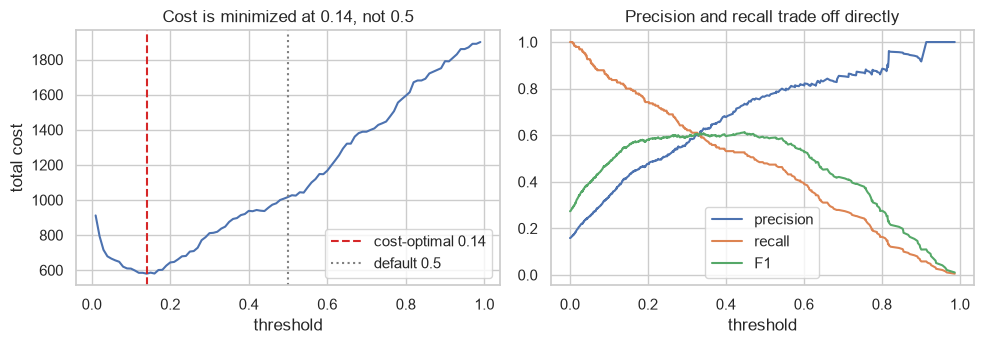

In [28]:
from sklearn.metrics import precision_recall_curve

prec, rec, pr_th = precision_recall_curve(yh_te, proba)
f1s = 2 * prec * rec / np.clip(prec + rec, 1e-12, None)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))

axes[0].plot(grid, costs)
axes[0].axvline(best, color="tab:red", ls="--", label=f"cost-optimal {best:.2f}")
axes[0].axvline(0.5, color="tab:gray", ls=":", label="default 0.5")
axes[0].set_xlabel("threshold"); axes[0].set_ylabel("total cost")
axes[0].set_title(f"Cost is minimized at {best:.2f}, not 0.5")
axes[0].legend()

axes[1].plot(pr_th, prec[:-1], label="precision")
axes[1].plot(pr_th, rec[:-1], label="recall")
axes[1].plot(pr_th, f1s[:-1], label="F1")
axes[1].set_xlabel("threshold")
axes[1].set_title("Precision and recall trade off directly")
axes[1].legend()

fig.tight_layout()
plt.show()

Two other threshold rules appear frequently, and both are what to use when nobody will give you costs:

| Rule | Picks the threshold that | Appropriate when |
|---|---|---|
| **Youden's J** | Maximizes `TPR − FPR` | Classes matter equally |
| **F1-optimal** | Maximizes F1 | Precision and recall matter equally |
| **Fixed-precision** | Achieves a required precision, maximizing recall subject to it | An alert queue with a capacity limit |

In [29]:
from sklearn.metrics import roc_curve

fpr, tpr, roc_th = roc_curve(yh_te, proba)
youden = roc_th[np.argmax(tpr - fpr)]
f1_best = pr_th[np.nanargmax(f1s[:-1])]

# Highest recall subject to precision >= 0.60
ok = prec[:-1] >= 0.60
capacity = pr_th[ok][np.argmax(rec[:-1][ok])] if ok.any() else np.nan


def describe(label, th):
    pred_t = (proba >= th).astype(int)
    print(f"{label:<22} {th:>5.2f}   flags {pred_t.sum():>4}"
          f"   precision {precision_score(yh_te, pred_t, zero_division=0):.3f}"
          f"   recall {recall_score(yh_te, pred_t):.3f}")


describe("default", 0.50)
describe("Youden's J", youden)
describe("F1-optimal", f1_best)
describe("precision >= 0.60", capacity)
describe("cost-optimal", best)

default                 0.50   flags  118   precision 0.771   recall 0.479
Youden's J              0.17   flags  333   precision 0.450   recall 0.789
F1-optimal              0.45   flags  136   precision 0.735   recall 0.526
precision >= 0.60       0.33   flags  193   precision 0.601   recall 0.611
cost-optimal            0.14   flags  374   precision 0.412   recall 0.811


**Common mistake — tuning the threshold on the test set.** The threshold is a parameter chosen from data,
so choosing it on the test set makes the reported score optimistic in exactly the way 8.2 described. Select
it on validation data or inside the cross-validation loop, then apply the frozen value to the test set.
`TunedThresholdClassifierCV` does this correctly.

In [30]:
from sklearn.model_selection import TunedThresholdClassifierCV

tuned = TunedThresholdClassifierCV(
    make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
    scoring="f1", cv=5, random_state=RANDOM_STATE,
).fit(Xh_tr, yh_tr)

print(f"threshold chosen by CV on the training data: {tuned.best_threshold_:.3f}")
print(f"test F1 at that threshold : {f1_score(yh_te, tuned.predict(Xh_te)):.4f}")
print(f"test F1 at the 0.5 default: {f1_score(yh_te, hard_clf.predict(Xh_te)):.4f}")

threshold chosen by CV on the training data: 0.308
test F1 at that threshold : 0.6020
test F1 at the 0.5 default: 0.5909


### 8.7 Probability Calibration

A model can rank cases perfectly and still output meaningless probabilities. **Calibration** asks a
different question from AUC: among all cases where the model said 0.7, did roughly 70% turn out positive?

This matters whenever the probability itself enters a decision — expected value, expected loss, a threshold
derived from costs (8.6.1), a downstream model consuming the score. It does not matter if you only need a
ranking.

In [31]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

Xc, yc = load_breast_cancer(return_X_y=True)
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc, yc, test_size=0.4, stratify=yc,
                                              random_state=RANDOM_STATE)

models = {
    "logistic": make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
    "random forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "gaussian NB": GaussianNB(),
    "SVC + sigmoid calibration": CalibratedClassifierCV(
        make_pipeline(StandardScaler(), SVC()), method="sigmoid", cv=3),
}

probas = {}
for name, m in models.items():
    m.fit(Xc_tr, yc_tr)
    probas[name] = m.predict_proba(Xc_te)[:, 1]
    print(f"{name:<27} ROC AUC {roc_auc_score(yc_te, probas[name]):.4f}"
          f"   Brier {brier_score_loss(yc_te, probas[name]):.4f}")

logistic                    ROC AUC 0.9989   Brier 0.0145


random forest               ROC AUC 0.9938   Brier 0.0338
gaussian NB                 ROC AUC 0.9915   Brier 0.0498
SVC + sigmoid calibration   ROC AUC 0.9979   Brier 0.0224


Read those two columns against each other. AUC measures **ranking**; the Brier score measures ranking *and*
calibration together. A model can lead on one and trail on the other, which is exactly why both belong in a
report.

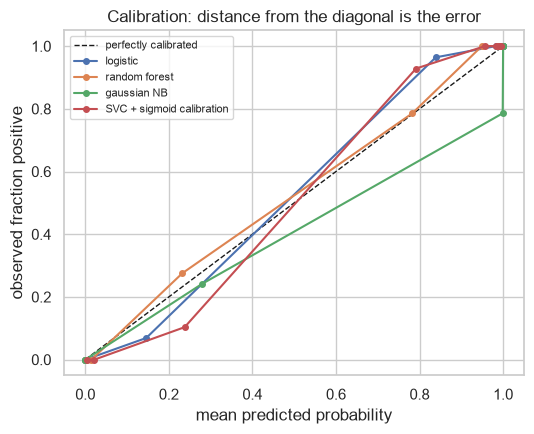

In [32]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="perfectly calibrated")

for name, p in probas.items():
    frac_pos, mean_pred = calibration_curve(yc_te, p, n_bins=8, strategy="quantile")
    ax.plot(mean_pred, frac_pos, "o-", label=name, markersize=4)

ax.set_xlabel("mean predicted probability")
ax.set_ylabel("observed fraction positive")
ax.set_title("Calibration: distance from the diagonal is the error")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

| Model family | Typical calibration | Why |
|---|---|---|
| Logistic regression | **Good** | It optimizes log loss, which is a proper scoring rule |
| Random forest | Under-confident at the extremes | Averaging votes pulls probabilities toward 0.5 |
| Gradient boosting | Over-confident | Optimizes a margin-like objective |
| Naive Bayes | **Poor** | The independence assumption (15.2) makes it wildly over-confident |
| SVM | No probabilities at all natively | Distances to a hyperplane are not probabilities |

`CalibratedClassifierCV` fixes calibration after the fact by fitting a small monotonic transform on
held-out predictions.

| Method | Fits | Use when |
|---|---|---|
| `sigmoid` (Platt) | A 2-parameter logistic curve | Little data; the distortion is roughly sigmoidal |
| `isotonic` | Any monotonic step function | More data (≳1000); a more flexible fix |

In [33]:
raw_nb = GaussianNB().fit(Xc_tr, yc_tr)
cal_sig = CalibratedClassifierCV(GaussianNB(), method="sigmoid", cv=5).fit(Xc_tr, yc_tr)
cal_iso = CalibratedClassifierCV(GaussianNB(), method="isotonic", cv=5).fit(Xc_tr, yc_tr)

for name, m in (("naive bayes, raw", raw_nb), ("+ sigmoid", cal_sig), ("+ isotonic", cal_iso)):
    p = m.predict_proba(Xc_te)[:, 1]
    print(f"{name:<20} Brier {brier_score_loss(yc_te, p):.4f}   "
          f"log loss {log_loss(yc_te, p):.4f}   AUC {roc_auc_score(yc_te, p):.4f}")

naive bayes, raw     Brier 0.0498   log loss 0.3084   AUC 0.9915
+ sigmoid            Brier 0.0500   log loss 0.2073   AUC 0.9910
+ isotonic           Brier 0.0416   log loss 0.1345   AUC 0.9902


Log loss improves substantially (0.31 → 0.13 with isotonic) while AUC barely moves. That is the expected
shape: calibration reshapes the probability scale, not the ordering.

**But look closely — AUC did move slightly.** A pure post-hoc calibration is a monotonic transform and
therefore *cannot* change the ranking or the AUC at all. `CalibratedClassifierCV(cv=5)` is not pure: it
refits the base estimator on each of five folds and averages the five calibrated outputs, which makes it a
small ensemble.

To calibrate an **already-fitted** model without refitting it, wrap it in `FrozenEstimator`. (Older code
passes `cv="prefit"` for this; that was removed in scikit-learn 1.9 in favour of the wrapper.)

In [34]:
from sklearn.frozen import FrozenEstimator

# Split the training data so the calibrator gets its own held-out slice.
Xf_fit, Xf_cal, yf_fit, yf_cal = train_test_split(Xc_tr, yc_tr, test_size=0.4, stratify=yc_tr,
                                                  random_state=RANDOM_STATE)

base = GaussianNB().fit(Xf_fit, yf_fit)
sigmoid_cal = CalibratedClassifierCV(FrozenEstimator(base), method="sigmoid").fit(Xf_cal, yf_cal)

p_base = base.predict_proba(Xc_te)[:, 1]
p_sig = sigmoid_cal.predict_proba(Xc_te)[:, 1]

print(f"AUC before calibration : {roc_auc_score(yc_te, p_base):.6f}")
print(f"AUC after  (sigmoid)   : {roc_auc_score(yc_te, p_sig):.6f}   <- exactly identical")
print(f"log loss before        : {log_loss(yc_te, p_base):.4f}")
print(f"log loss after         : {log_loss(yc_te, p_sig):.4f}   <- much better")

AUC before calibration : 0.991691
AUC after  (sigmoid)   : 0.991691   <- exactly identical
log loss before        : 0.3395
log loss after         : 0.1958   <- much better


Exactly identical AUC, far better log loss. Platt scaling is a strictly increasing function, so it cannot
reorder anything — calibration doing precisely one job and nothing else.

**Isotonic is different, and the reason is worth knowing.** It fits a monotonic *step* function, so distinct
input scores can map to the same output value. Those ties change AUC slightly, because AUC awards a tied
pair half credit instead of full credit.

In [35]:
iso_cal = CalibratedClassifierCV(FrozenEstimator(base), method="isotonic").fit(Xf_cal, yf_cal)
p_iso = iso_cal.predict_proba(Xc_te)[:, 1]

print(f"distinct probability values, sigmoid : {len(np.unique(p_sig)):>4} of {len(p_sig)}")
print(f"distinct probability values, isotonic: {len(np.unique(p_iso)):>4} of {len(p_iso)}   <- ties")
print(f"\nAUC, sigmoid  : {roc_auc_score(yc_te, p_sig):.6f}")
print(f"AUC, isotonic : {roc_auc_score(yc_te, p_iso):.6f}   <- moved, because of the ties")
print(f"log loss, isotonic: {log_loss(yc_te, p_iso):.4f}")

distinct probability values, sigmoid :  136 of 228
distinct probability values, isotonic:   18 of 228   <- ties

AUC, sigmoid  : 0.991691
AUC, isotonic : 0.990415   <- moved, because of the ties
log loss, isotonic: 0.1265


The practical consequence: **if you only need a ranking, do not bother calibrating; if a probability feeds
an expected-value calculation, you must.** 8.9.1 walks straight into that trap and back out of it.

### 8.8 Baselines and Honest Comparison

#### 8.8.1 Always have a baseline

A score with nothing to compare it to is uninterpretable (1.6). `DummyClassifier` and `DummyRegressor` cost
one line.

| Strategy | Predicts | Baseline for |
|---|---|---|
| `most_frequent` | The majority class | Accuracy on imbalanced data |
| `stratified` | Random, matching class proportions | AUC (gives ~0.5) |
| `prior` | The class prior as a probability | Log loss, Brier |
| `uniform` | Uniformly at random | — |
| `mean` / `median` (regressor) | A constant | R² (gives ~0) |

In [36]:
from sklearn.dummy import DummyRegressor

for strategy in ("most_frequent", "stratified", "prior", "uniform"):
    d = DummyClassifier(strategy=strategy, random_state=RANDOM_STATE).fit(Xr_tr, yr_tr)
    p = d.predict_proba(Xr_te)[:, 1]
    print(f"{strategy:<14} accuracy {accuracy_score(yr_te, d.predict(Xr_te)):.4f}"
          f"   AUC {roc_auc_score(yr_te, p):.4f}"
          f"   AP {average_precision_score(yr_te, p):.4f}")

print(f"\nthe real model  accuracy {accuracy_score(yr_te, rare_clf.predict(Xr_te)):.4f}"
      f"   AUC {roc_auc_score(yr_te, proba_rare):.4f}"
      f"   AP {average_precision_score(yr_te, proba_rare):.4f}")

most_frequent  accuracy 0.9900   AUC 0.5000   AP 0.0100
stratified     accuracy 0.9933   AUC 0.6667   AP 0.3400
prior          accuracy 0.9900   AUC 0.5000   AP 0.0100
uniform        accuracy 0.5133   AUC 0.5000   AP 0.0100

the real model  accuracy 0.9900   AUC 0.9843   AP 0.3131


#### 8.8.2 A difference smaller than its uncertainty is not a difference

Cross-validation gives $k$ scores, so it gives a standard error (2.8.3). Two models whose means differ by
less than that are not distinguishable on this data.

In [37]:
from sklearn.model_selection import RepeatedStratifiedKFold

rcv = RepeatedStratifiedKFold(n_splits=5, n_repeats=6, random_state=RANDOM_STATE)

candidates = {
    "logistic": make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
    "random forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "naive bayes": GaussianNB(),
}

fold_scores = {}
for name, m in candidates.items():
    s = cross_val_score(m, X_train, y_train, cv=rcv, scoring="roc_auc")
    fold_scores[name] = s
    print(f"{name:<15} {s.mean():.4f} +/- {s.std() / np.sqrt(len(s)):.4f} (s.e., n={len(s)} folds)")

logistic        0.9917 +/- 0.0019 (s.e., n=30 folds)


random forest   0.9873 +/- 0.0022 (s.e., n=30 folds)


naive bayes     0.9874 +/- 0.0015 (s.e., n=30 folds)


In [38]:
from scipy.stats import ttest_rel

a, b = fold_scores["logistic"], fold_scores["random forest"]
diff = a.mean() - b.mean()
stat, p_value = ttest_rel(a, b)   # PAIRED: the same folds were used for both

print(f"logistic - random forest: {diff:+.4f}")
print(f"paired t-test p-value   : {p_value:.4f}")
print("->", "a real difference" if p_value < 0.05 else "not distinguishable on this data")

logistic - random forest: +0.0044
paired t-test p-value   : 0.0711
-> not distinguishable on this data


The test is **paired** because both models were evaluated on the same folds, which removes the
fold-difficulty variation and makes the comparison far more sensitive than an unpaired test would be.

**Common mistake — treating the best cross-validation score as an estimate of performance.** 8.2 showed
selection inflates the maximum. If you compared twenty models by CV, the winner's CV score is optimistic;
the test set exists precisely to give an uninflated number, and 23.8's nested CV is the version that works
when there is no separate test set.

In [39]:
best_name = max(fold_scores, key=lambda k: fold_scores[k].mean())
best_model = candidates[best_name].fit(X_train, y_train)
best_test = roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1])

print(f"winner: {best_name}")
print(f"  its CV score (used for selection): {fold_scores[best_name].mean():.4f}   <- optimistic")
print(f"  its TEST score (used once)       : {best_test:.4f}   <- the number to report")

winner: logistic
  its CV score (used for selection): 0.9917   <- optimistic
  its TEST score (used once)       : 0.9981   <- the number to report


### 8.9 In Practice

#### 8.9.1 A worked case: an evaluation report a business can act on

The request: *"The churn model is done. Is it good, and what threshold should we run it at?"*

"Good" is not a property of a model — it is a property of a model **plus a metric plus a threshold plus a
cost structure**. This section produces the report that answers the real question, using the retention
economics as the deciding input.

In [40]:
DOMAIN_RULES = {"age": (16, 100), "satisfaction_score": (1, 10), "monthly_charges": (0, 500)}


def prepare(df):
    out = df.drop_duplicates().copy()
    out["total_charges"] = pd.to_numeric(out["total_charges"], errors="coerce")
    out.loc[out["total_charges"].isna() & (out["tenure_months"] <= 1), "total_charges"] = 0.0
    out["gender"] = out["gender"].str.strip().str.lower().replace({"male": "m", "female": "f"})
    for col, (lo, hi) in DOMAIN_RULES.items():
        out[col] = out[col].where(out[col].between(lo, hi))
    return out


from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

data = prepare(pd.read_csv("data/customers.csv"))
NUMERIC = ["age", "tenure_months", "monthly_charges", "total_charges",
           "support_tickets", "last_login_days", "satisfaction_score"]
CATEGORICAL = ["gender", "city", "plan"]

churn_tr, churn_te = train_test_split(data, test_size=0.25, stratify=data["churned"],
                                      random_state=RANDOM_STATE)

encoder = ColumnTransformer([
    ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), NUMERIC),
    ("cat", make_pipeline(SimpleImputer(strategy="most_frequent"),
                          OneHotEncoder(handle_unknown="ignore")), CATEGORICAL),
])

churn_model = make_pipeline(encoder, LogisticRegression(max_iter=5000, class_weight="balanced"))
churn_model.fit(churn_tr[NUMERIC + CATEGORICAL], churn_tr["churned"])

churn_proba = churn_model.predict_proba(churn_te[NUMERIC + CATEGORICAL])[:, 1]
y_churn_te = churn_te["churned"].to_numpy()
print(f"test rows {len(y_churn_te)}, positives {y_churn_te.sum()} ({y_churn_te.mean():.1%})")

test rows 250, positives 35 (14.0%)


**Step 1 — report against a baseline, with uncertainty.** A single number is not a finding.

In [41]:
X_churn_tr = churn_tr[NUMERIC + CATEGORICAL]
y_churn_tr = churn_tr["churned"]

cv_auc = cross_val_score(churn_model, X_churn_tr, y_churn_tr,
                         cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=4, random_state=RANDOM_STATE),
                         scoring="roc_auc")
dummy_auc = cross_val_score(DummyClassifier(strategy="stratified", random_state=RANDOM_STATE),
                            X_churn_tr, y_churn_tr, cv=5, scoring="roc_auc")

print(f"model CV ROC AUC : {cv_auc.mean():.4f} +/- {cv_auc.std() / np.sqrt(len(cv_auc)):.4f}")
print(f"dummy CV ROC AUC : {dummy_auc.mean():.4f}")
print(f"model TEST ROC AUC: {roc_auc_score(y_churn_te, churn_proba):.4f}")
print(f"model TEST AP     : {average_precision_score(y_churn_te, churn_proba):.4f}"
      f"   (chance = {y_churn_te.mean():.4f})")

model CV ROC AUC : 0.7983 +/- 0.0101
dummy CV ROC AUC : 0.5077
model TEST ROC AUC: 0.8043
model TEST AP     : 0.5175   (chance = 0.1400)


**Step 2 — pick the metric from the decision, not from habit.** Churn is 14% positive, so accuracy is
disqualified (8.5.1). The business acts on the *positive* class — customers to send a retention offer to —
so average precision and recall at a workable precision are the relevant numbers (8.5.2).

**Step 3 — turn the economics into a threshold.** These are the numbers to ask a stakeholder for:

In [42]:
OFFER_COST = 500.0        # cost of a retention offer, sent to anyone we flag
CUSTOMER_VALUE = 4000.0   # value retained if a real churner accepts
ACCEPT_RATE = 0.30        # fraction of flagged real churners who stay because of the offer

def net_benefit(threshold):
    flagged = churn_proba >= threshold
    tp_ = int((flagged & (y_churn_te == 1)).sum())
    fp_ = int((flagged & (y_churn_te == 0)).sum())
    return tp_ * ACCEPT_RATE * CUSTOMER_VALUE - (tp_ + fp_) * OFFER_COST, tp_, fp_


grid = np.linspace(0.05, 0.95, 91)
benefits = np.array([net_benefit(t)[0] for t in grid])
best_t = grid[benefits.argmax()]

print(f"best threshold      : {best_t:.2f}")
print(f"net benefit there   : {benefits.max():,.0f}")
print(f"net benefit at 0.50 : {benefits[np.abs(grid - 0.5).argmin()]:,.0f}")
print(f"\nbreak-even precision = offer cost / expected value per save"
      f" = {OFFER_COST:.0f} / {ACCEPT_RATE * CUSTOMER_VALUE:.0f} = "
      f"{OFFER_COST / (ACCEPT_RATE * CUSTOMER_VALUE):.3f}")

best threshold      : 0.90
net benefit there   : 5,100
net benefit at 0.50 : -11,000

break-even precision = offer cost / expected value per save = 500 / 1200 = 0.417


**At the default threshold this campaign loses ₹11,000.** That is the finding, and it comes from one line of
arithmetic rather than from the model: an offer costs ₹500 and a successful save is worth
$0.30 \times 4000 = ₹1{,}200$, so the campaign only pays where **precision exceeds 0.417**. The model does
not reach that precision until the threshold is very high, so the profitable operating point is a small,
narrowly targeted campaign.

In [43]:
# Precision by threshold, against the break-even line.
break_even = OFFER_COST / (ACCEPT_RATE * CUSTOMER_VALUE)

for th in (0.3, 0.5, 0.7, 0.8, 0.9):
    pred_t = (churn_proba >= th).astype(int)
    p = precision_score(y_churn_te, pred_t, zero_division=0)
    print(f"threshold {th:.1f}  flags {pred_t.sum():>3}   precision {p:.3f}   "
          f"{'PROFITABLE' if p > break_even else 'loses money'}")

threshold 0.3  flags 135   precision 0.222   loses money
threshold 0.5  flags  82   precision 0.305   loses money
threshold 0.7  flags  39   precision 0.462   PROFITABLE
threshold 0.8  flags  21   precision 0.571   PROFITABLE
threshold 0.9  flags   9   precision 0.889   PROFITABLE


In [44]:
value, tp_at_best, fp_at_best = net_benefit(best_t)
pred_at_best = (churn_proba >= best_t).astype(int)

print(f"at threshold {best_t:.2f}:")
print(f"  customers flagged : {pred_at_best.sum()} of {len(pred_at_best)}")
print(f"  true churners caught: {tp_at_best} of {y_churn_te.sum()}"
      f"  (recall {recall_score(y_churn_te, pred_at_best):.2f})")
print(f"  offers wasted       : {fp_at_best}"
      f"  (precision {precision_score(y_churn_te, pred_at_best, zero_division=0):.2f})")
print(f"  net benefit         : {value:,.0f}")

at threshold 0.90:
  customers flagged : 9 of 250
  true churners caught: 8 of 35  (recall 0.23)
  offers wasted       : 1  (precision 0.89)
  net benefit         : 5,100


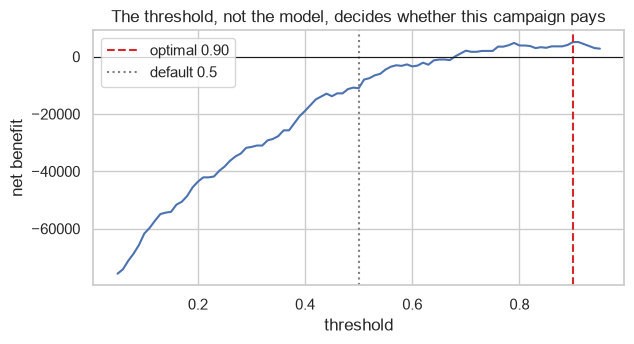

In [45]:
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(grid, benefits)
ax.axvline(best_t, color="tab:red", ls="--", label=f"optimal {best_t:.2f}")
ax.axvline(0.5, color="tab:gray", ls=":", label="default 0.5")
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("threshold"); ax.set_ylabel("net benefit")
ax.set_title("The threshold, not the model, decides whether this campaign pays")
ax.legend()
fig.tight_layout()
plt.show()

Everything therefore hinges on the three economic inputs, none of which came from the model. Vary the
acceptance rate — the number nobody actually measured — and the recommendation changes completely.

In [46]:
print(f"{'accept rate':>12}{'break-even prec':>17}{'best threshold':>16}{'flagged':>9}{'net benefit':>13}")
for rate in (0.10, 0.20, 0.30, 0.50, 0.70):
    be = OFFER_COST / (rate * CUSTOMER_VALUE)
    vals = []
    for t in grid:
        flagged = churn_proba >= t
        tp_ = int((flagged & (y_churn_te == 1)).sum())
        fp_ = int((flagged & (y_churn_te == 0)).sum())
        vals.append(tp_ * rate * CUSTOMER_VALUE - (tp_ + fp_) * OFFER_COST)
    vals = np.array(vals)
    t_star = grid[vals.argmax()]
    print(f"{rate:>12.0%}{be:>17.3f}{t_star:>16.2f}"
          f"{int((churn_proba >= t_star).sum()):>9}{vals.max():>13,.0f}")

 accept rate  break-even prec  best threshold  flagged  net benefit
         10%            1.250            0.95        4         -400
         20%            0.625            0.90        9        1,900
         30%            0.417            0.90        9        5,100
         50%            0.250            0.57       66       17,000
         70%            0.179            0.57       66       37,000


At a 10% acceptance rate the campaign cannot be run profitably at any threshold worth the name; at 70% it
should be sent to a large fraction of the book. **The model is the same in every row.** The acceptance rate
is the single most valuable number missing from this analysis, and it can only be obtained by running a
randomized holdout — which is a stronger recommendation than any model improvement.

**Step 4 — check the probabilities are usable.** Step 3's arithmetic multiplies a probability by a value,
so it is only valid if the probabilities are calibrated (8.7). `class_weight="balanced"` deliberately
distorts them, which is worth knowing before quoting an expected value.

In [47]:
plain_model = make_pipeline(encoder, LogisticRegression(max_iter=5000))
plain_model.fit(X_churn_tr, y_churn_tr)
plain_proba = plain_model.predict_proba(churn_te[NUMERIC + CATEGORICAL])[:, 1]

print(f"observed churn rate in test      : {y_churn_te.mean():.3f}")
print(f"mean predicted, class_weight=bal : {churn_proba.mean():.3f}   <- inflated by reweighting")
print(f"mean predicted, plain            : {plain_proba.mean():.3f}   <- matches the base rate")
print(f"\nBrier, balanced : {brier_score_loss(y_churn_te, churn_proba):.4f}")
print(f"Brier, plain    : {brier_score_loss(y_churn_te, plain_proba):.4f}")
print(f"AUC,   balanced : {roc_auc_score(y_churn_te, churn_proba):.4f}")
print(f"AUC,   plain    : {roc_auc_score(y_churn_te, plain_proba):.4f}")

observed churn rate in test      : 0.140
mean predicted, class_weight=bal : 0.382   <- inflated by reweighting
mean predicted, plain            : 0.140   <- matches the base rate

Brier, balanced : 0.1743
Brier, plain    : 0.0922
AUC,   balanced : 0.8043
AUC,   plain    : 0.8066


The two models rank almost identically — 0.8043 against 0.8066 AUC — and their probabilities mean entirely
different things. `class_weight="balanced"` pushes the mean predicted probability to **0.382 against a true
base rate of 0.140**, and nearly doubles the Brier score. Every expected-value figure in step 3 was
computed from those inflated probabilities.

**For a cost-based decision, use the unreweighted model, or calibrate explicitly (8.7). Reserve
`class_weight` for cases where you only need a ranking, or a threshold you will tune anyway** (22.4).

**Step 5 — the report.**

> **Is the model good?** Yes, modestly. It reaches **0.804 test ROC AUC** and **0.518 average precision**
> against a 0.140 chance baseline, on 250 held-out customers. Cross-validated AUC on the training data is
> 0.798 ± 0.010, so the test figure is consistent with it rather than a lucky split, and a stratified dummy
> scores 0.508.
>
> **Should we run the campaign?** **Not at the default threshold — it loses about ₹11,000 on this sample.**
> An offer costs ₹500 and a successful save is worth 0.30 × ₹4,000 = ₹1,200, so the campaign only pays
> where precision exceeds **0.417**. This model only clears that bar above a threshold of roughly 0.8.
>
> **What is the profitable operating point?** Threshold **0.90**: flag 9 of 250 customers, catch 8 of 35
> real churners (23% recall) at 89% precision, for about **₹5,100** net. That is a narrow, high-confidence
> campaign, not a broad one.
>
> **What would change the answer?** The acceptance rate, which nobody has measured. At 10% the campaign is
> unprofitable at every threshold; at 50% the optimal threshold drops and the campaign should go to a much
> larger group. Measuring it with a randomized holdout is worth more than any further modelling.
>
> **Caveat on the numbers above.** They were computed from a `class_weight="balanced"` fit whose
> probabilities average 0.382 against a true rate of 0.140. The rankings are reliable; the probabilities are
> not. Every expected-value figure should be recomputed from the unweighted or calibrated model before
> anyone commits budget.

Two things make that a report rather than a score. The headline finding is **negative** — the obvious way to
run this model loses money — and the most valuable recommendation is to go and measure a business
parameter, not to improve the model. Neither is visible from an AUC.

#### 8.9.2 Which metric, and which protocol

| Situation | Metric | Not |
|---|---|---|
| Balanced classes, equal error costs | Accuracy | — |
| Imbalanced classes | Average precision, balanced accuracy, MCC | **Accuracy** (8.5.1) |
| Rare positives, false alarms are expensive | Precision at fixed recall, or AP | ROC AUC (8.5.2) |
| Both classes matter, threshold not yet chosen | ROC AUC | F1 — it depends on a threshold |
| The probability feeds an expected-value decision | Log loss or Brier, **plus** a calibration curve | AUC alone (8.7) |
| Small classes matter as much as large | Macro-averaged F1 | Weighted or micro (8.5.4) |
| Regression, outliers are genuine and costly | RMSE | MAE |
| Regression, outliers are noise | MAE or MedAE | RMSE (8.4.1) |
| Regression, target can be zero | MAE | MAPE (8.4.3) |
| Comparing models with different feature counts | Adjusted R², or a test score | R² (8.4.2) |
| Rows share an entity | `GroupKFold` | `KFold` (8.3.3) |
| Data is time-ordered | `TimeSeriesSplit` | Any shuffled split (8.3.4) |
| Choosing among many models | CV on train, then the test set once | The best CV score as the estimate (8.8.2) |

#### 8.9.3 What goes wrong in production

| Failure | What it looks like | Where |
|---|---|---|
| **The threshold was never revisited** | Base rates shifted; precision quietly collapsed | 8.6, 24.9 |
| **Offline metric ≠ business outcome** | AUC improves, revenue does not | 8.9.1 |
| **Class balance shifted** | Precision falls with no change to the model — the denominator moved | 8.5.1 |
| **Threshold tuned on the test set** | Reported precision unreachable in production | 8.6 |
| **Probabilities used as probabilities without calibration** | Expected-value calculations systematically wrong | 8.7 |
| **Grouped or temporal leakage in the CV** | Excellent offline scores, immediate live failure | 8.3.3, 8.3.4 |
| **The reported score was the best of many** | The model underperforms its own paperwork | 8.2, 8.8.2 |

Two of these are worth the last word because they need no model change to happen.

**Precision depends on the base rate.** Precision is $TP/(TP+FP)$, and how many false positives a fixed
threshold produces depends on how many negatives arrive. If churn falls from 14% to 7% because a previous
campaign worked, the same model at the same threshold flags a similar number of customers and catches half
as many real ones — precision halves, and nothing about the model changed. Monitor the input distribution
and the flag rate, not only the score (24.9).

**A threshold is a decision, and decisions expire.** It was derived from costs that were true when someone
quoted them. Offer costs change, customer value changes, acceptance rates change. The threshold is the
cheapest thing in the entire pipeline to re-derive and the most commonly forgotten.

In [48]:
# --- 8. Model Evaluation and Validation — scratch cell ---# Experiments for this chapter. Promote anything worth keeping into the# relevant section as a proper example cell.